# ALPSS Results Analysis

This notebook fetches all `pdv_alpss_result` items from the API, compiles them into a DataFrame, and visualizes key aspects of the shock experiment dataset:

- Quality pass rates across the three validation checks
- Distributions of velocity and spall strength
- Per-sample (IGSN) velocity comparisons
- Processing pipeline version breakdown
- Measurement uncertainty vs. value

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import requests
from dotenv import find_dotenv, load_dotenv

load_dotenv(find_dotenv())

sys.path.insert(0, str(Path.cwd().parent.parent / 'src'))
from aimdl_examples import (
    coerce_types,
    fetch_and_parse,
    get_girder_client,
    paginate_datafiles,
    enrich_alpss_with_material_properties
)

## Fetch all results

Parse every `pdv_alpss_result` CSV into a dict and assemble into a DataFrame. `coerce_types` converts the ~28 numeric columns from strings to floats.

In [2]:
with requests.Session() as session:
    gc = get_girder_client(session=session)
    rows = paginate_datafiles(
        gc,
        'pdv_alpss_result',
        lambda item: fetch_and_parse(gc, item),
        extraFields='["meta.prov", "meta.runId"]',
    )

df = pd.DataFrame(rows)
df = coerce_types(df)
df = enrich_alpss_with_material_properties(df, gc)
print(f'Loaded {len(df)} results with {len(df.columns)} columns')

Loaded 3297 results with 48 columns


## Data overview

Each row is one shock experiment. Key column groups:
- **`Velocity OK`, `Spall OK`, `HEL OK`** — boolean quality flags
- **`Velocity at Max Compression`** — peak velocity (m/s)
- **`Spall Strength`, `Strain Rate`** — derived shock metrics
- **`HEL Strength (GPa)`** — Hugoniot Elastic Limit
- **`alpss_version`, `alpss_dagster_version`** — processing pipeline versions
- **`igsn`** — sample identifier

In [3]:
print(f'Shape: {df.shape}')
print(f'IGSNs: {df["igsn"].nunique()}')
print(f'ALPSS versions: {sorted(df["alpss_version"].dropna().unique())}')
df.head(3)

Shape: (3297, 48)
IGSNs: 154
ALPSS versions: ['1.7.1']


,Date,File Name,Run Time,Error Message,Velocity OK,Velocity at Max Compression,Time at Max Compression,Velocity at Max Compression Freq Uncertainty,Velocity at Max Compression Vel Uncertainty,Carrier Frequency,...,igsn,itemId,runId,alpss_dagster_version,alpss_version,material_type,material_thickness,material_c0,material_c_l,material_density
0,Jun 11 2026 04:42 PM,C1--20250807--00006.csv,0 days 00:00:00.793132,velocity: Velocity 4.873084541713192 did not e...,False,4.873085,0.000002,1.246665e+06,0.966165,1.860000e+09,...,JHAMAA00001-S5R4C3,6a296cd70b116ccbfdcc2022,ac25c1d9-ebdf-4bdc-9ce1-b692c2e78a7e,0.1.1,1.7.1,<NA>,<NA>,<NA>,<NA>,<NA>
1,Jun 11 2026 04:43 PM,C1--20250807--00009.csv,0 days 00:00:00.783401,velocity: Velocity 1.013024448780469 did not e...,False,1.013024,0.000002,1.813703e+06,1.405619,1.860058e+09,...,JHAMAA00001-S5R4C3,6a296ced0b116ccbfdcc2125,ac25c1d9-ebdf-4bdc-9ce1-b692c2e78a7e,0.1.1,1.7.1,<NA>,<NA>,<NA>,<NA>,<NA>
2,Jun 11 2026 04:42 PM,C1--20250807--00005.csv,0 days 00:00:00.794346,velocity: Velocity 2.317337597437216 did not e...,False,2.317338,0.000002,1.345923e+06,1.043090,1.824000e+09,...,JHAMAA00001-S5R4C3,6a296cd00b116ccbfdcc200b,ac25c1d9-ebdf-4bdc-9ce1-b692c2e78a7e,0.1.1,1.7.1,<NA>,<NA>,<NA>,<NA>,<NA>


## Quality pass rates

Three independent quality checks gate the derived metrics. A result must pass `Velocity OK` to have a valid velocity; `Spall OK` and `HEL OK` gate their respective metrics.

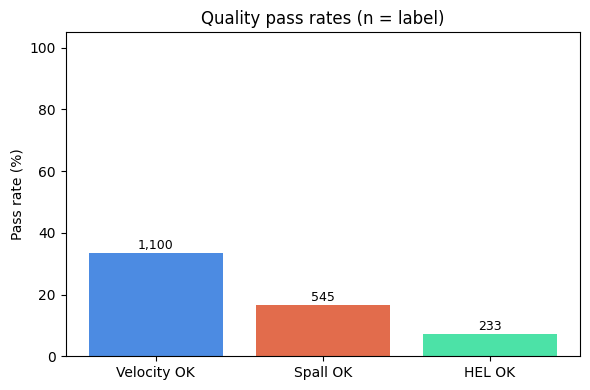

In [4]:
quality_cols = ['Velocity OK', 'Spall OK', 'HEL OK']
present = [c for c in quality_cols if c in df.columns]
pass_rates = {c: df[c].sum() / len(df) * 100 for c in present}
counts = {c: int(df[c].sum()) for c in present}

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(pass_rates.keys(), pass_rates.values(), color=['#4C8BE2', '#E26C4C', '#4CE2A7'])
for bar, (col, n) in zip(bars, counts.items()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{n:,}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Pass rate (%)')
ax.set_ylim(0, 105)
ax.set_title('Quality pass rates (n = label)')
plt.tight_layout()
plt.show()

## Velocity distribution

Peak velocity at max compression for experiments that passed the velocity quality check.

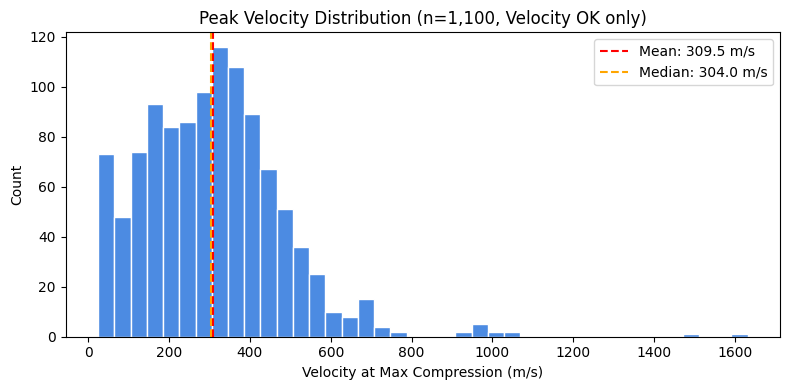

In [5]:
passing = df[df['Velocity OK'] == True]
vel = passing['Velocity at Max Compression'].dropna()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(vel, bins=40, edgecolor='white', color='#4C8BE2')
ax.axvline(vel.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Mean: {vel.mean():.1f} m/s')
ax.axvline(vel.median(), color='orange', linestyle='--', linewidth=1.5,
           label=f'Median: {vel.median():.1f} m/s')
ax.set_xlabel('Velocity at Max Compression (m/s)')
ax.set_ylabel('Count')
ax.set_title(f'Peak Velocity Distribution (n={len(vel):,}, Velocity OK only)')
ax.legend()
plt.tight_layout()
plt.show()

## Spall strength distribution

Spall strength for experiments that passed the spall quality check, with uncertainty shown as error bars on the histogram.

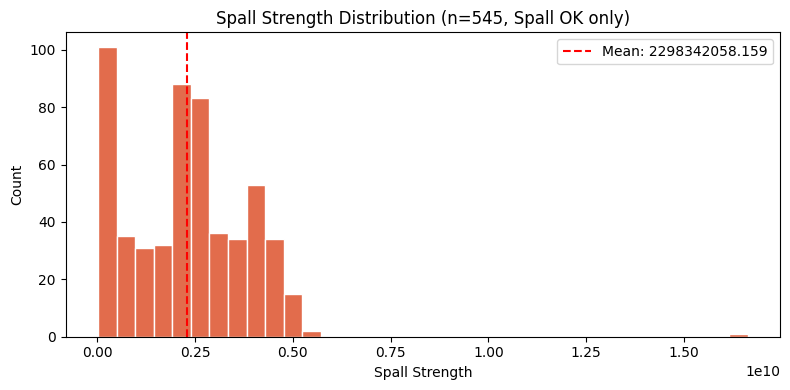

In [6]:
spall_ok = df[df['Spall OK'] == True]
spall = spall_ok['Spall Strength'].dropna()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(spall, bins=35, edgecolor='white', color='#E26C4C')
ax.axvline(spall.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Mean: {spall.mean():.3f}')
ax.set_xlabel('Spall Strength')
ax.set_ylabel('Count')
ax.set_title(f'Spall Strength Distribution (n={len(spall):,}, Spall OK only)')
ax.legend()
plt.tight_layout()
plt.show()

## Velocity by sample (IGSN)

Box plots of peak velocity grouped by sample, for the samples with the most measurements. Each box shows the distribution of experiments on that sample.

/var/folders/yp/l_t6f1mn0yqclvv5qdshg2xr0000gn/T/ipykernel_50577/655963287.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=top_igsns, vert=True, patch_artist=True)


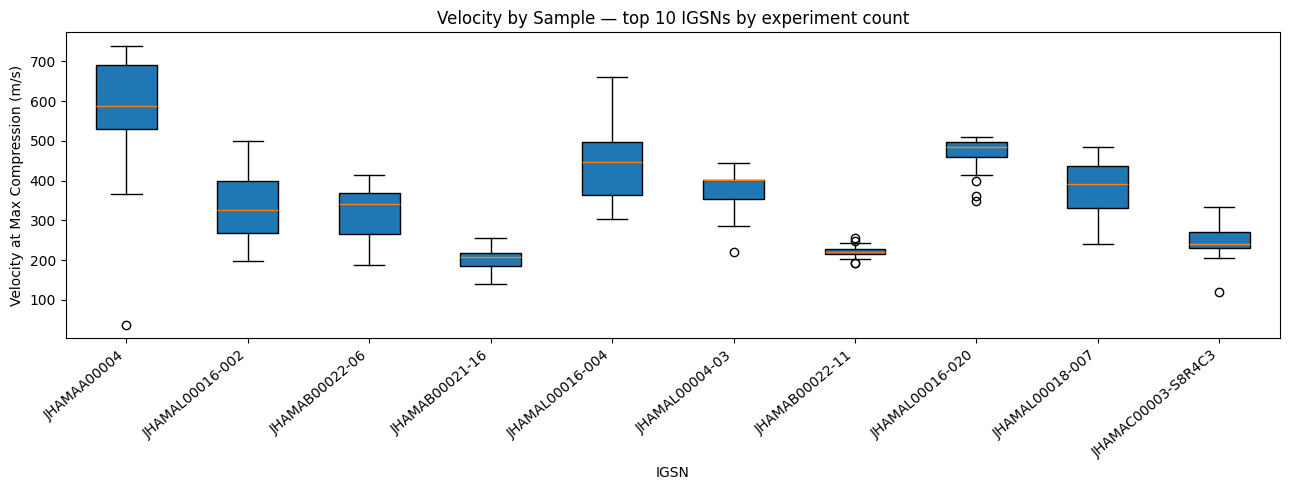

In [7]:
N_SAMPLES = 10
top_igsns = passing['igsn'].value_counts().head(N_SAMPLES).index
groups = [
    passing[passing['igsn'] == igsn]['Velocity at Max Compression'].dropna().values
    for igsn in top_igsns
]

fig, ax = plt.subplots(figsize=(13, 5))
ax.boxplot(groups, labels=top_igsns, vert=True, patch_artist=True)
ax.set_xlabel('IGSN')
ax.set_ylabel('Velocity at Max Compression (m/s)')
ax.set_title(f'Velocity by Sample — top {N_SAMPLES} IGSNs by experiment count')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

## Measurement vs. uncertainty

Scatter plot of velocity against its uncertainty estimate. Ideally uncertainty should be small relative to the measurement value; clusters or trends here can reveal systematic issues.

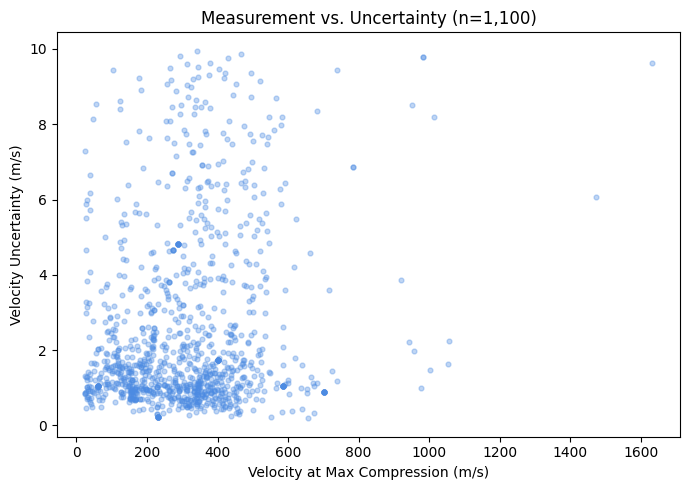

In [8]:
col_vel = 'Velocity at Max Compression'
col_unc = 'Velocity at Max Compression Vel Uncertainty'
scatter_data = passing[[col_vel, col_unc]].dropna()

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(scatter_data[col_vel], scatter_data[col_unc], alpha=0.35, s=12, color='#4C8BE2')
ax.set_xlabel('Velocity at Max Compression (m/s)')
ax.set_ylabel('Velocity Uncertainty (m/s)')
ax.set_title(f'Measurement vs. Uncertainty (n={len(scatter_data):,})')
plt.tight_layout()
plt.show()